In [24]:
###############################################################################
# 0.  Packages
###############################################################################
using LinearAlgebra      # Gaussian smearing + histogram


const PATH_FILES     = raw"/media/r_floren/FernandoM/VASP/NbP/Supercell/nCollinear/00_Data"
const PATH_FILES_H   = raw"/media/r_floren/FernandoM/VASP/NbP/Supercell/nCollinear_bridge_gpu/05_V2W/out_v2w_20250531_014414"
const PATH_FILES_H_S = raw"/media/r_floren/FernandoM/VASP/NbP/Supercell_217/nCollinear_H/05_V2W/out_v2w_20250607_000616"

"/media/r_floren/FernandoM/VASP/NbP/Supercell_217/nCollinear_H/05_V2W/out_v2w_20250607_000616"

## Pre-processing
This section contains all the functions to load the DOS and PDOS elements calculated through AB-inition (VASP) from the file PROCAR on the NSCF. Here, we construct the DOS and PDOS elements via PROCARData which contains the information of atomic orbitals in the brilluoin zone. This data contains the total number of kpoints $N_k$, total number of bands $N_{bands}$, number of ions $N_{ions}$, the corresponding energies $E_{n,k}$, the projections on certain atomic orbital of certain atom, and the k-vector weight.

## Density of States
I this section I write the function to calculate the DOS from VASP

## Collinear spin (non SOC) without Hydrogen atom

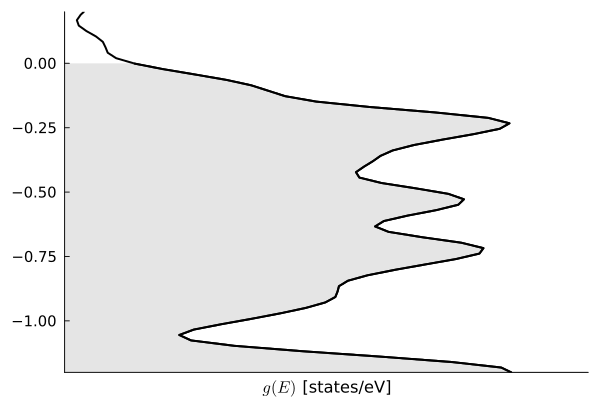

In [68]:
function plot_DOS_nSOC()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = DOS_PROCAR_nSOC()
end
plot_DOS_nSOC()

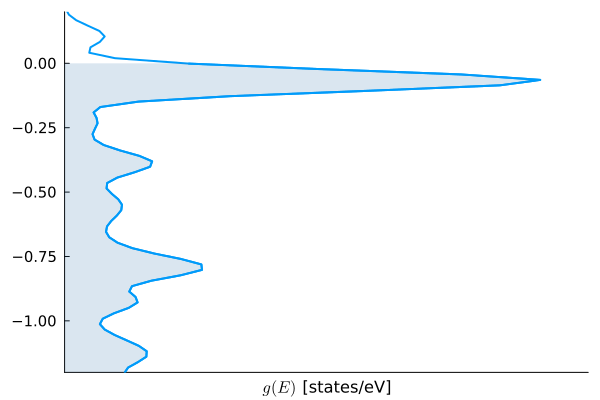

In [15]:
function plot_PDOS_nSOC()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = PDOS_PROCAR_nSOC()
end
plot_PDOS_nSOC()

## Collinear Spin (non SOC) with hydrogen atom

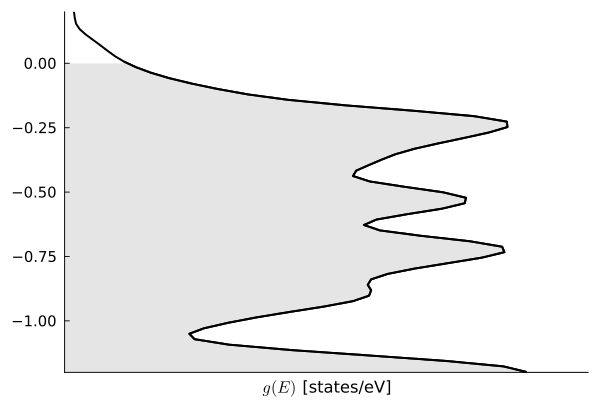

In [73]:
function plot_DOS_nSOC_H()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = DOS_PROCAR_nSOC_H()
end
plot_DOS_nSOC_H()

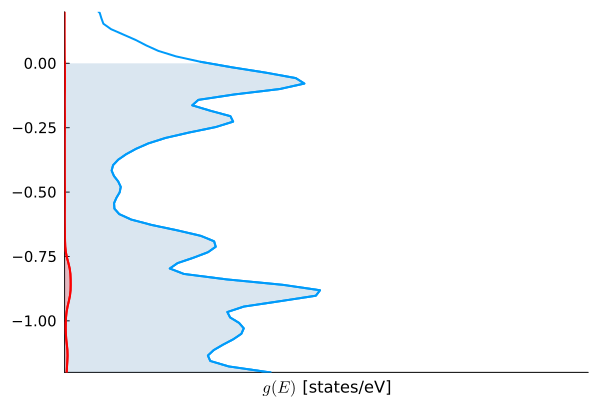

In [17]:
function plot_PDOS_nSOC_H()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = PDOS_PROCAR_nSOC_H()
end
plot_PDOS_nSOC_H()

## nonCollinear spin (SOC) without hydrogen atom

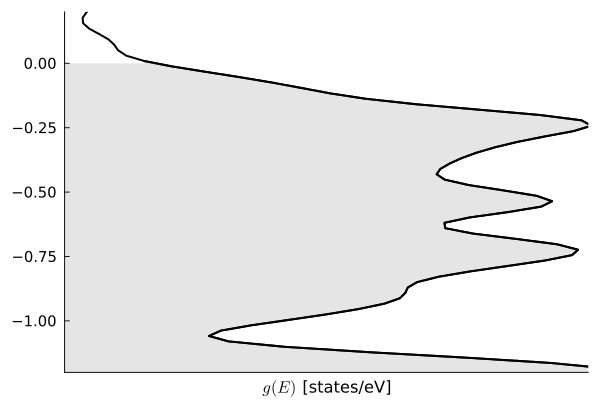

In [76]:
function plot_DOS_SOC()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = DOS_PROCAR_SOC()
end
plot_DOS_SOC()

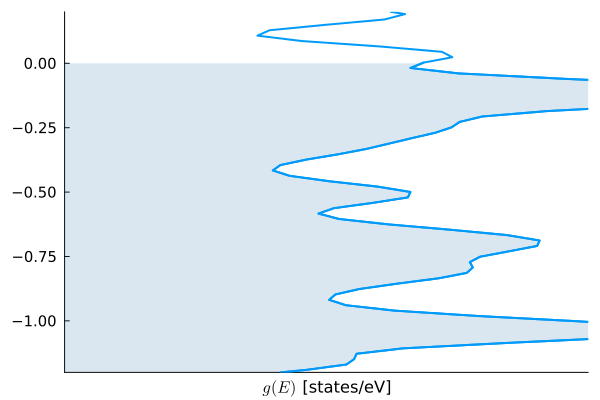

In [19]:
function plot_PDOS_SOC()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = PDOS_PROCAR_SOC()
end
plot_PDOS_SOC()

## non Collinear spin (SOC) with hydrogen atom

In [77]:
function plot_DOS_SOC_H()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = DOS_PROCAR_SOC_H()
end
plot_DOS_SOC_H()

UndefVarError: UndefVarError: `fa1se` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

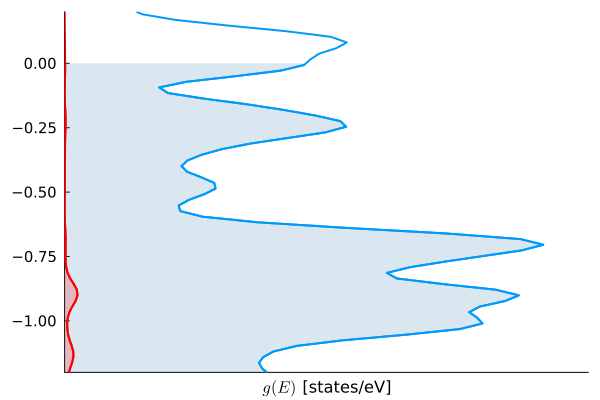

In [21]:
function plot_PDOS_SOC_H()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = PDOS_PROCAR_SOC_H()
end
plot_PDOS_SOC_H()

## non Collinear Spin (SOC) with Hydrogen atom in Supercell 2x1x7

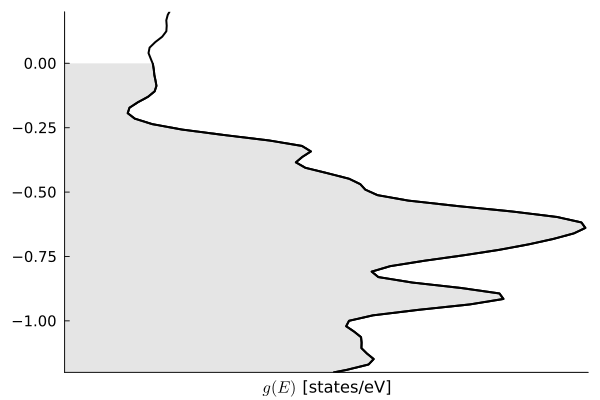

In [78]:
function plot_DOS_SOC_H_S()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = DOS_PROCAR_SOC_H_S()
end
plot_DOS_SOC_H_S()

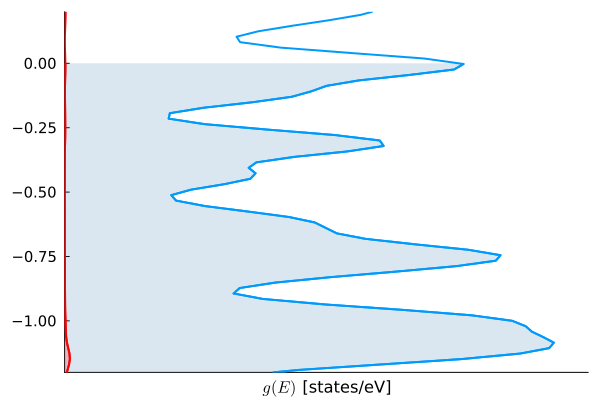

In [23]:
function plot_PDOS_SOC_H_S()
    include("/media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/DOS.jl")
    p1 = PDOS_PROCAR_SOC_H_S() 
end
plot_PDOS_SOC_H_S()

### Occupation Number

In [24]:
# Fermi Dirac Distribution
function FD_dist(ϵ::Float64, T::Float64, E_fermi::Float64)
    return 1/(exp((ϵ - E_fermi)/T) + 1)
end
function electron_occupancy(PATH_HDF5::String)
    T = 0.001 # Temperature in eV
    p1 = plot()
    e_fermi = 5.5337 # Fermi energy
    k = 1:506
    fid = h5open(joinpath(PATH_HDF5,"DOS_H_101x101.h5"), "r")
    Energies = read(fid, "eigenvalues")[:,:,k] 
    Energies .= Energies .- e_fermi


    # Initialize arrays to store reconstructed data
    proj0_H_up = read(fid, "proj_H_up")[:,:,k]
    proj0_H_dn = read(fid, "proj_H_dn")[:,:,k]

    close(fid)

    LINE_WIDTH = [2.0, 2.0, 0.75, 1.0]
    LINE_COLOR = [:black, :blue, :green, :red]
    FILL_ALPHA = 0.2

    nkx, nky, nbands = size(Energies)
    electron_occupancy_k_up = zeros(nkx, nky)
    electron_occupancy_k_dn = zeros(nkx, nky)
    for i in 1:nkx
        for j in 1:nky
            for b in 1:nbands
                electron_occupancy_k_up[i,j] += FD_dist(Energies[i,j,b], T, 0.0) * 
                                                  proj0_H_up[i,j,b] 
                electron_occupancy_k_dn[i,j] += FD_dist(Energies[i,j,b], T, 0.0) *
                                                  proj0_H_dn[i,j,b]
            end
        end
    end
    electron_occupancy_up = sum(electron_occupancy_k_up) ./ (nkx * nky)
    electron_occupancy_dn = sum(electron_occupancy_k_dn) ./ (nkx * nky)

    return electron_occupancy_up, electron_occupancy_dn

end
electron_occupancy(PATH_FILES_H)

UndefVarError: UndefVarError: `PATH_FILES_H` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Adsorption with Hydrogen molecule in Supercell 1x1x7

In [25]:
"""
    COOP(hr, Nx, Ny; kmax=506, fname="COOP.h5")

Parallel COOP/COHP calculator.  
`hr` is your Wannier TB object (must provide `bloch_hamiltonian(hr,k)` and
`hr.H_R[a,b,Rindex]` access).
"""
function DOS(hr, Nx::Int, Ny::Int; kmax::Int=1010, fname::String="DOS_H_51x101.h5")

    kx_vec = range(-0.5, 0.5, length = Nx)
    ky_vec = range(-0.5, 0.5, length = Ny)

    #######################################################################
    # 1.  Create the HDF5 skeleton (once, in the main thread)
    #######################################################################

    ds_names = ["eigenvalues", "proj_H_up", "proj_H_dn",
                    "proj1", "proj2", "proj3", "proj4", 
                    "proj5", "proj6", "proj7", "proj8"]

    h5open(fname, "w") do f
        for n in ds_names
            create_dataset(f, n, Float64, (Nx,Ny,kmax), chunk=(1,Ny,kmax))
        end
    end

    #######################################################################
    # 2.  Parallel loop over kx
    #######################################################################
    lk   = ReentrantLock()

    @sync @threads for ix in 1:Nx
        # --- allocate local buffers (Ny × kmax) --------------------------
        local_eigs     = zeros(Float64, Ny, kmax)
        local_H_up     = zeros(Float64, Ny, kmax)
        local_H_dn     = similar(local_H_up)

        local_p1       = similar(local_H_up);  local_p2     = similar(local_H_up)
        local_p3       = similar(local_H_up);  local_p4     = similar(local_H_up)
        local_p5       = similar(local_H_up);  local_p6     = similar(local_H_up)
        local_p7       = similar(local_H_up);  local_p8     = similar(local_H_up)

        # --- iterate over ky --------------------------------------------
        for (iy, ky) in enumerate(ky_vec)
            Hk          = bloch_hamiltonian(hr, SVector(kx_vec[ix], ky, 0.0))
            E, V        = eigen(Hk)                         # Eigen object
            local_eigs[iy, :] = real.(E)                    # copy eigenvalues

            for i in 1:kmax
                # shorthand
                local_H_up[iy, i] = abs.(V[1,i]).^2
		local_H_dn[iy, i] = abs.(V[2,i]).^2

                local_p1[iy, i] = sum(abs.(V[3:22, i]).^2)
                local_p2[iy, i] = sum(abs.(V[563:578, i]).^2)
                local_p3[iy, i] = sum(abs.(V[23:42, i]).^2)
                local_p4[iy, i] = sum(abs.(V[579:594, i]).^2)
                local_p5[iy, i] = sum(abs.(V[43:62, i]).^2)
                local_p6[iy, i] = sum(abs.(V[595:610, i]).^2)
                local_p7[iy, i] = sum(abs.(V[63:82, i]).^2)
                local_p8[iy, i] = sum(abs.(V[611:626, i]).^2)
            end
        end # ky loop

        ###################################################################
        # 3.  Flush this kx-slice to disk (single writer section)
        ###################################################################
        lock(lk) do
            h5open(fname, "r+") do file
                file["eigenvalues"][ix,:,:] = local_eigs
                file["proj_H_up"][ix,:,:] = local_H_up
		file["proj_H_dn"][ix,:,:] = local_H_dn

                file["proj1"][ix, :, :] = local_p1
                file["proj2"][ix, :, :] = local_p2
                file["proj3"][ix, :, :] = local_p3
                file["proj4"][ix, :, :] = local_p4
                file["proj5"][ix, :, :] = local_p5
                file["proj6"][ix, :, :] = local_p6
                file["proj7"][ix, :, :] = local_p7
                file["proj8"][ix, :, :] = local_p8
            end
        end
    end # kx loop
end


# DOS(hr, 51, 101)

LoadError: LoadError: UndefVarError: `@threads` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at /media/r_floren/FernandoM/VASP/JuliaCodes/NbP/VASP/DOS/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X30sZmlsZQ==.jl:1

In [26]:
function plot_DOS_H_S(PATH_HDF5::String, σ::Float64)
    p1 = plot()
    e_fermi = 5.7468 # Fermi energy
    k = 1:1010
    fid = h5open(joinpath(PATH_HDF5,"DOS_H_51x101.h5"), "r")
    Energies = read(fid, "eigenvalues")[:,:,k] 
    Energies .= Energies .- e_fermi


    # Initialize arrays to store reconstructed data
    proj0_H_up = read(fid, "proj_H_up")[:,:,k]
    proj0_H_dn = read(fid, "proj_H_dn")[:,:,k]

    proj1   = read(fid, "proj1")[:,:,k]
    proj2   = read(fid, "proj2")[:,:,k]
    proj3   = read(fid, "proj3")[:,:,k]
    proj4   = read(fid, "proj4")[:,:,k]
    proj5   = read(fid, "proj5")[:,:,k]
    proj6   = read(fid, "proj6")[:,:,k]
    proj7   = read(fid, "proj7")[:,:,k]
    proj8   = read(fid, "proj8")[:,:,k]


    close(fid)

    LINE_WIDTH = [2.0, 2.0, 0.75, 1.0]
    LINE_COLOR = [:black, :blue, :green, :red]
    FILL_ALPHA = 0.2

    final_proj0 = (proj0_H_dn .+ proj0_H_up) .* 5.0
    final_proj = proj1 .+ proj2 .+ proj3 .+ proj4 .+ proj5 .+ proj6 .+ proj7 .+ proj8

    enn = range(-6.5, 9, length=1000)
    p = sortperm(vcat(Energies...))
    Energies = vcat(Energies...)[p]
    final_proj = vcat(final_proj...)[p]
    final_proj0 = vcat(final_proj0...)[p]

    DOS = zeros(length(enn))
    PDOS = zeros(length(enn))
    bulk_PDOS = zeros(length(enn))
    proj0 = zeros(length(enn))

    for i in 1:length(enn)
        tmp = abs.(Energies .- enn[i]) .< σ
        DOS[i] = length(Energies[tmp])
        tmp_PDOS = mean(final_proj[tmp])
        PDOS[i] = DOS[i] * tmp_PDOS
        bulk_PDOS[i] = DOS[i] * (1 - tmp_PDOS)
        tmp_proj0 = mean(final_proj0[tmp])
        proj0[i] = DOS[i] * tmp_proj0
    end
    tmp = findmin(abs.(enn))[2]

    # plot!(p1, DOS, enn, 
    #     label = "DOS",
    #     linecolor = LINE_COLOR[1],
    #     linewidth = LINE_WIDTH[1]
    #     )
    plot!(p1, PDOS, enn, 
        label = "Surface PDOS",
        linecolor = 1,
        linewidth = LINE_WIDTH[2],
        alpha = 0.5
    )
    plot!(p1, proj0, enn, 
        label = "H PDOS",
        linecolor = 2,
        linewidth = LINE_WIDTH[2],
        alpha = 0.5
    )
    # plot!(p1, DOS[1:tmp], enn[1:tmp], 
    #     fill = (FILL_ALPHA, 0, LINE_COLOR[1]),
    #     lw=LINE_WIDTH[1],
    #     lc=LINE_COLOR[1],
    #     label=false
    #     )
    plot!(p1, PDOS[1:tmp], enn[1:tmp], 
        fill = (FILL_ALPHA, 0, :steelblue),
        lw= LINE_WIDTH[1],
        lc=1,
        label=false
        )
    plot!(p1, proj0[1:tmp], enn[1:tmp], 
        fill = (FILL_ALPHA, 0, :red),
        lw=LINE_WIDTH[1],
        lc=2,
        label=false
        )
    plot!(p1,
        # ylims = (-1.2, 0.2),
        xlims = (0, maximum(PDOS) * 1.2),
        yticks = false,
        xticks = false,
        # ylabel = "Energy (eV)",
        xlabel = "states/eV",
        # title = "NbP",
        legendfontsize = 12,
        yguidefontsize = 18,
        xguidefontsize = 12,
        xtickfontsize = 12,
        ytickfontsize = 12,
        size=(150, 550)
    )
    # savefig(p1, "/media/r_floren/FernandoM/Bandstructure/VASP/NbP/Supercell/Figures/Fermi_Surface/FS_-0_05.png")
    return p1
end
p2 = plot_DOS_H_S(PATH_FILES_H_S, 0.005)

UndefVarError: UndefVarError: `PATH_FILES_H_S` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Occupation Number

In [27]:
function electron_occupancy_S217(PATH_HDF5::String)
    T = 0.001 # Temperature in eV
    p1 = plot()
    e_fermi = 5.7468 # Fermi energy
    k = 1:1010
    fid = h5open(joinpath(PATH_HDF5,"DOS_H_51x101.h5"), "r")
    Energies = read(fid, "eigenvalues")[:,:,k] 
    Energies .= Energies .- e_fermi


    # Initialize arrays to store reconstructed data
    proj0_H_up = read(fid, "proj_H_up")[:,:,k]
    proj0_H_dn = read(fid, "proj_H_dn")[:,:,k]

    close(fid)

    LINE_WIDTH = [2.0, 2.0, 0.75, 1.0]
    LINE_COLOR = [:black, :blue, :green, :red]
    FILL_ALPHA = 0.2

    nkx, nky, nbands = size(Energies)
    electron_occupancy_k_up = zeros(nkx, nky)
    electron_occupancy_k_dn = zeros(nkx, nky)
    for i in 1:nkx
        for j in 1:nky
            for b in 1:nbands
                electron_occupancy_k_up[i,j] += FD_dist(Energies[i,j,b], T, 0.0) * 
                                                  proj0_H_up[i,j,b] 
                electron_occupancy_k_dn[i,j] += FD_dist(Energies[i,j,b], T, 0.0) *
                                                  proj0_H_dn[i,j,b]
            end
        end
    end
    electron_occupancy_up = sum(electron_occupancy_k_up) ./ (nkx * nky)
    electron_occupancy_dn = sum(electron_occupancy_k_dn) ./ (nkx * nky)

    return electron_occupancy_up, electron_occupancy_dn

end
electron_occupancy_S217(PATH_FILES_H_S)

UndefVarError: UndefVarError: `PATH_FILES_H_S` not defined in `Main`
Suggestion: check for spelling errors or missing imports.